In [1]:
import os
import numpy as np
import simplegrad as sg
import matplotlib.pyplot as plt
from tqdm import tqdm

%matplotlib inline

In [2]:
sg.seed(2026)
sg.default_dtype("float32")
sg.default_device("cuda:0" if sg.cuda_is_available() else "cpu")
print(f"Using device: {sg.get_default_device()}")

train_path = "../datasets/cifar10/cifar10/train/"
test_path = "../datasets/cifar10/cifar10/test/"
labels_path = "../datasets/cifar10/cifar10/labels.txt"

NUM_EPOCHS = 50
LR = 3e-4
BATCH_SIZE = 64
VAL_SPLIT = 0.05   # fraction of training data used for validation
PATIENCE = 5       # early stopping: val checks without improvement

Using device: cuda:0


In [3]:
#!curl -L -o /home/examples/cifar10.zip https://www.kaggle.com/api/v1/datasets/download/oxcdcd/cifar10
#!mkdir -p /home/examples/datasets/cifar10/
#!unzip -q /home/examples/cifar10.zip -d /home/examples/datasets/cifar10/
#!rm -rf /home/examples/cifar10.zip

In [4]:
with open(labels_path) as f:
    labels = f.read().splitlines()
print(labels)
print(len(labels))

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
10


In [5]:
def load_image(path):
    img = plt.imread(path)
    if img.dtype == np.uint8:
        img = img.astype(np.float32) / 255.0
    else:
        img = img.astype(np.float32)
    return img.transpose(2, 0, 1)  # HWC -> CHW


def augment(img):
    """Random horizontal flip + random crop. Expects CHW float32."""
    if np.random.random() < 0.5:
        img = img[:, :, ::-1].copy()
    pad = 4
    img = np.pad(img, ((0, 0), (pad, pad), (pad, pad)), mode="reflect")
    h0 = np.random.randint(0, 2 * pad + 1)
    w0 = np.random.randint(0, 2 * pad + 1)
    return img[:, h0:h0 + 32, w0:w0 + 32]


def get_files_and_labels(path):
    files, lbls = [], []
    for d in os.walk(path):
        label = os.path.basename(d[0])
        for f in d[2]:
            files.append(os.path.join(d[0], f))
            lbls.append(labels.index(label))
    return files, np.array(lbls)


train_files, train_labels = get_files_and_labels(train_path)
test_files, test_labels = get_files_and_labels(test_path)

print(f"Train: {len(train_files)} files")
print(f"Test:  {len(test_files)} files")

Train: 50000 files
Test:  10000 files


Train: 47500  Val: 2500  Test: 10000


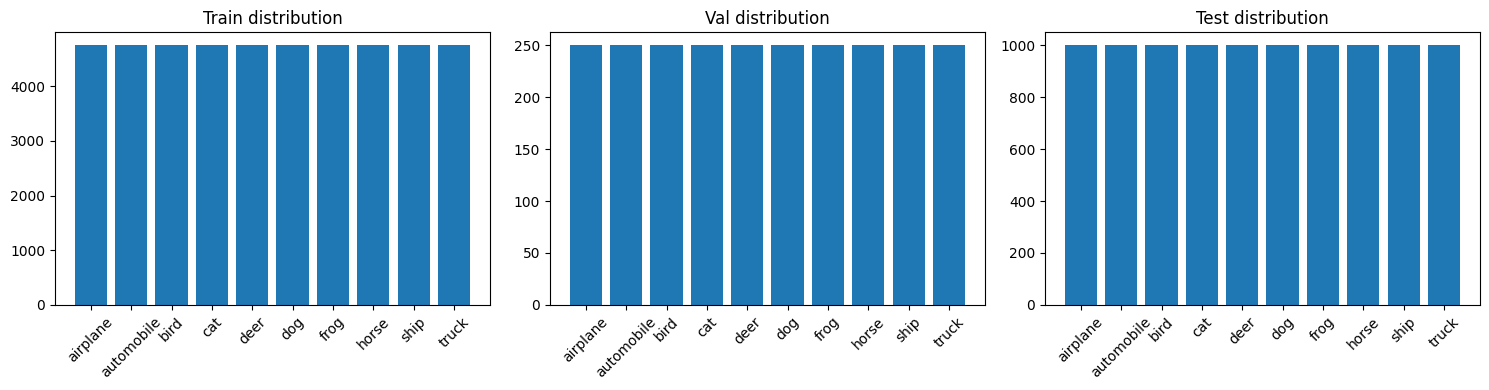

In [6]:
# Stratified split: VAL_SPLIT % of each class kept for validation
rng = np.random.default_rng(2026)
val_files, val_labels_list = [], []
train_files_s, train_labels_s = [], []

for cls in range(len(labels)):
    idx = np.where(train_labels == cls)[0]
    rng.shuffle(idx)
    n_val = max(1, int(len(idx) * VAL_SPLIT))
    val_files.extend([train_files[i] for i in idx[:n_val]])
    val_labels_list.extend([cls] * n_val)
    train_files_s.extend([train_files[i] for i in idx[n_val:]])
    train_labels_s.extend([cls] * (len(idx) - n_val))

train_files  = train_files_s
train_labels = np.array(train_labels_s)
val_labels_arr = np.array(val_labels_list)

print(f"Train: {len(train_files)}  Val: {len(val_files)}  Test: {len(test_files)}")

# Label distribution check
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, lbl) in zip(axes, [("Train", train_labels), ("Val", val_labels_arr), ("Test", test_labels)]):
    counts = [int(np.sum(lbl == c)) for c in range(len(labels))]
    ax.bar(labels, counts)
    ax.set_title(f"{name} distribution")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

(32, 32, 3)
5 dog


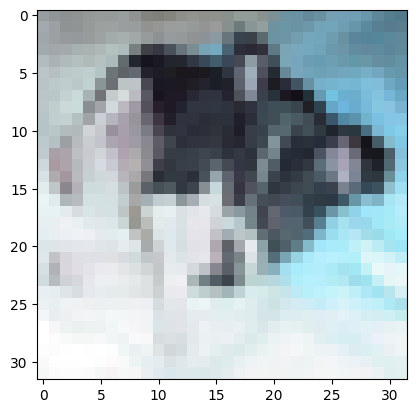

In [7]:
index = 25000
im = plt.imread(train_files[index])
print(im.shape)
print(train_labels[index], labels[train_labels[index]])
plt.imshow(im)
plt.show()

In [8]:
def one_hot(indices: np.ndarray, num_classes: int) -> sg.Tensor:
    oh = np.zeros((len(indices), num_classes), dtype=np.float32)
    oh[np.arange(len(indices)), indices.astype(int)] = 1.0
    return sg.Tensor(oh)


# pre-load test set
test_imgs     = sg.Tensor(np.array([load_image(f) for f in test_files], dtype=np.float32))
test_labels_oh = one_hot(test_labels, len(labels))
test_labels_t  = sg.Tensor(test_labels)

# pre-load val set (5% of train, stratified)
val_imgs      = sg.Tensor(np.array([load_image(f) for f in val_files], dtype=np.float32))
val_labels_oh  = one_hot(val_labels_arr, len(labels))
val_labels_t   = sg.Tensor(val_labels_arr)

In [9]:
model = sg.nn.Sequential(
    # Block 1: 32x32 -> 16x16
    sg.nn.Conv2d(3, 32, kernel_size=3, stride=1, pad_width=1),
    sg.nn.Norm(normalized_shape=[1, 32, 1, 1], dims=[0]),
    sg.nn.ReLU(),
    sg.nn.MaxPool2d(kernel_size=2, stride=2),
    # Block 2: 16x16 -> 8x8
    sg.nn.Conv2d(32, 64, kernel_size=3, stride=1, pad_width=1),
    sg.nn.Norm(normalized_shape=[1, 64, 1, 1], dims=[0]),
    sg.nn.ReLU(),
    sg.nn.MaxPool2d(kernel_size=2, stride=2),
    # Block 3: 8x8 -> 4x4
    sg.nn.Conv2d(64, 128, kernel_size=3, stride=1, pad_width=1),
    sg.nn.Norm(normalized_shape=[1, 128, 1, 1], dims=[0]),
    sg.nn.ReLU(),
    sg.nn.MaxPool2d(kernel_size=2, stride=2),
    # Classifier
    sg.nn.Flatten(),
    sg.nn.Linear(128 * 4 * 4, 256),
    sg.nn.ReLU(),
    sg.nn.Dropout(p=0.4),
    sg.nn.Linear(256, 10),
)
model.summary()

Parameters of Sequential

Parameter            Shape           Trainable Parameters                    
------------------------------------------------------------
modules.0.weight     (32, 3, 3, 3)   864                                     
modules.0.bias       (32,)           32                                      
modules.1.weight     (1, 32, 1, 1)   32                                      
modules.1.bias       (1, 32, 1, 1)   32                                      
modules.4.weight     (64, 32, 3, 3)  18432                                   
modules.4.bias       (64,)           64                                      
modules.5.weight     (1, 64, 1, 1)   64                                      
modules.5.bias       (1, 64, 1, 1)   64                                      
modules.8.weight     (128, 64, 3, 3) 73728                                   
modules.8.bias       (128,)          128                                     
modules.9.weight     (1, 128, 1, 1)  128               

In [10]:
opt = sg.opt.AdamW(model, lr=LR, beta_1=0.9, beta_2=0.999, eps=1e-8, weight_decay=1e-2)

steps_per_epoch = len(train_files) // BATCH_SIZE
sch = sg.sch.CosineAnnealingLR(opt, T_0=NUM_EPOCHS * steps_per_epoch, lr_min=1e-5, lr_max=LR)

loss_fn = sg.nn.CELoss()

In [11]:
tr = sg.Tracker("./experiments")
tr.set_experiment("cifar10_cnn")
tr.start_run(
    name="cifar10_cnn",
    config=dict(lr=LR, batch_size=BATCH_SIZE, num_epochs=NUM_EPOCHS, optimizer="AdamW", weight_decay=1e-2, scheduler="CosineAnnealingLR"),
)

Connected to existing experiment database at experiments/cifar10_cnn.db


5

In [12]:
best_val_loss = float("inf")
no_improve = 0
global_step = 0
stopped_early = False

model.set_train_mode()
for epoch in tqdm(range(NUM_EPOCHS), desc="training"):
    perm = np.random.permutation(len(train_files))
    epoch_loss, num_batches = 0.0, 0

    for i in range(0, len(train_files), BATCH_SIZE):
        idx = perm[i : i + BATCH_SIZE]
        x_batch = sg.Tensor(np.array([augment(load_image(train_files[j])) for j in idx], dtype=np.float32))
        y_batch = one_hot(np.array([train_labels[j] for j in idx]), len(labels))

        loss = loss_fn(model(x_batch), y_batch)
        opt.zero_grad()
        loss.backward()
        opt.step()
        sch.step()

        tr.record("train_loss", loss.values.item(), global_step)
        epoch_loss += loss.values.item()
        num_batches += 1
        global_step += 1

    with sg.no_grad():
        model.set_eval_mode()
        val_preds = model(val_imgs)
        val_loss = loss_fn(val_preds, val_labels_oh).values.item()
        pred_classes = sg.argmax(val_preds, dim=1)
        model.set_train_mode()

    val_acc = float((pred_classes.values == val_labels_t.values).mean())
    tr.record("val_loss", val_loss, global_step)
    tr.record("val_accuracy", val_acc, global_step)
    print(f"Epoch {epoch + 1}/{NUM_EPOCHS}  train_loss={epoch_loss / num_batches:.4f}  val_loss={val_loss:.4f}  val_accuracy={val_acc:.4%}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch + 1}.")
            stopped_early = True
            break

run_id = tr.end_run()
print(f"\nTraining {'stopped early' if stopped_early else 'complete'}. Best val_loss={best_val_loss:.4f}")

training:   2%|▏         | 1/50 [00:25<20:49, 25.50s/it]

Epoch 1/50  train_loss=1.4803  val_loss=1.1711  val_accuracy=60.8800%


training:   4%|▍         | 2/50 [00:47<18:55, 23.66s/it]

Epoch 2/50  train_loss=1.1647  val_loss=0.9859  val_accuracy=67.6000%


training:   6%|▌         | 3/50 [01:09<17:58, 22.95s/it]

...

Epoch 48/50  train_loss=0.5171  val_loss=0.4983  val_accuracy=85.1200%


training:  98%|█████████▊| 49/50 [18:26<00:22, 22.09s/it]

Epoch 49/50  train_loss=0.5198  val_loss=0.4972  val_accuracy=84.9200%


training:  98%|█████████▊| 49/50 [18:48<00:23, 23.04s/it]

Epoch 50/50  train_loss=0.5178  val_loss=0.5781  val_accuracy=82.8000%
Early stopping at epoch 50.

Training stopped early. Best val_loss=0.4961


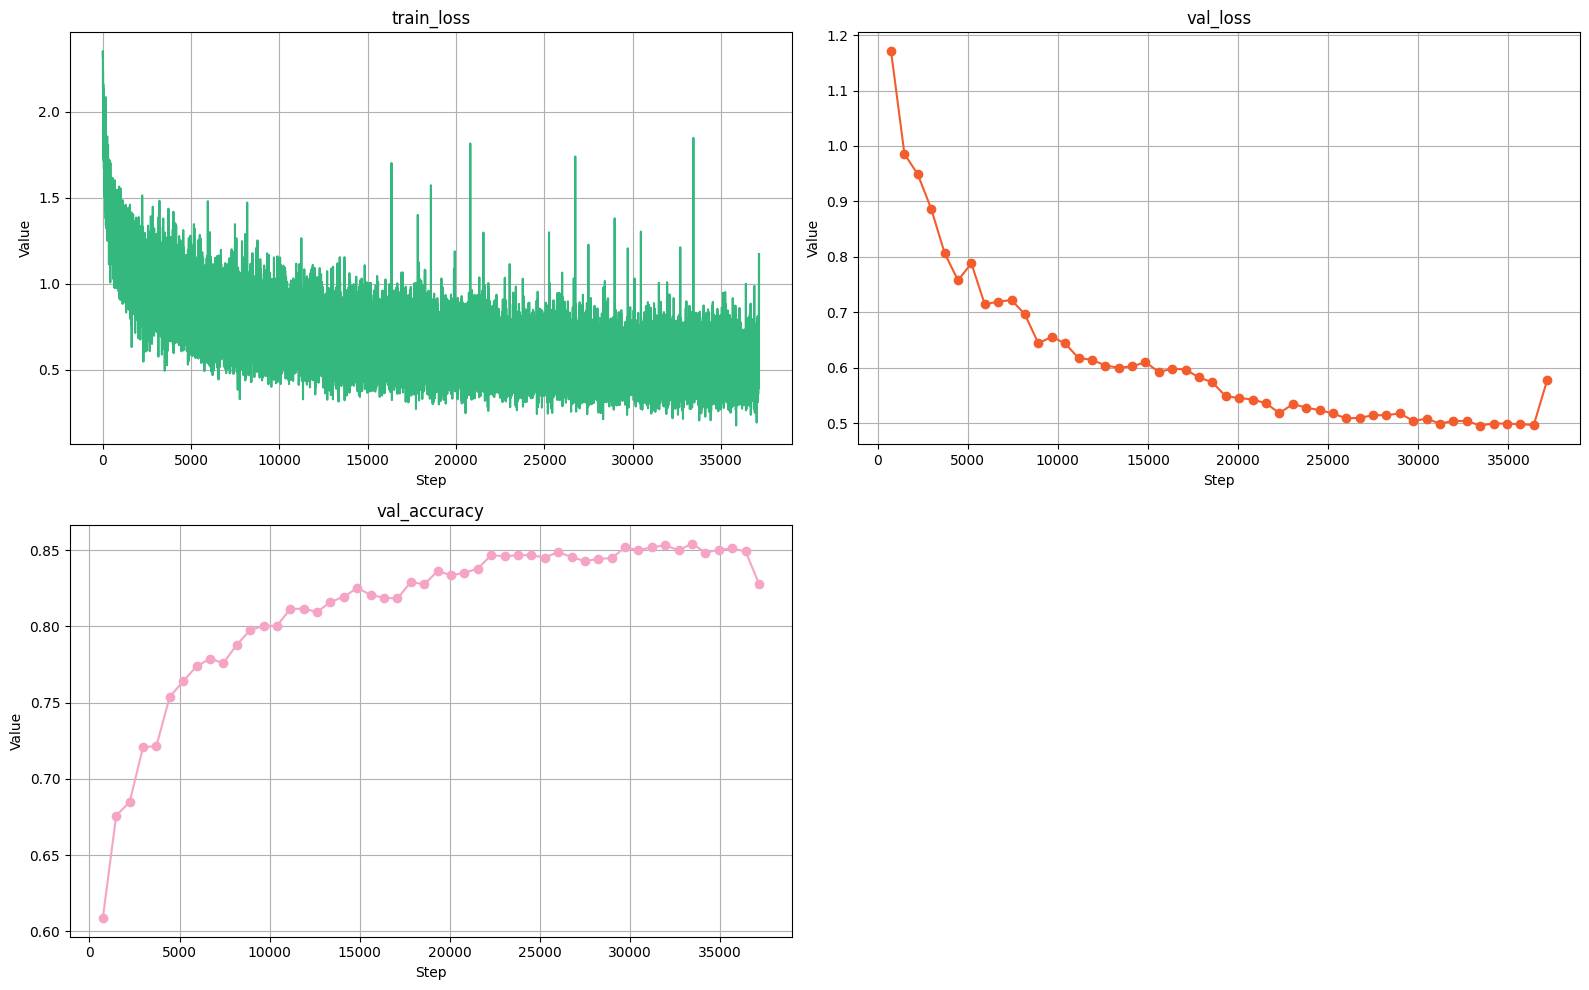

In [13]:
results = tr.get_results(run_id)
sg.vis.plot(results)

In [14]:
with sg.no_grad():
    model.set_eval_mode()
    pred_classes = sg.argmax(model(test_imgs), dim=1)

accuracy = float((pred_classes.values == test_labels_t.values).mean())
print(f"Test accuracy: {accuracy:.4%}")

Test accuracy: 82.2700%


In [15]:
with sg.no_grad():
    model.set_eval_mode()
    sample = model(sg.Tensor(np.array([load_image(test_files[0])], dtype=np.float32)))

sg.vis.graph(sample)
tr.save_comp_graph(tensor=sample, run_id=run_id)

Saving computation graph for run 5...
